In [ ]:
# deep Learning <Models> Enough

In [ ]:
# Fusion without Attention

In [ ]:
# Word + Transformers Embeddings 

Primary processing device: cuda

=== CNN1D ===
Epoch 1/5, Val Loss: 0.6759
Epoch 2/5, Val Loss: 0.6578
Epoch 3/5, Val Loss: 0.6354
Epoch 4/5, Val Loss: 0.6149
Epoch 5/5, Val Loss: 0.5985
Accuracy: 0.7122, Precision: 0.7263, Recall: 0.7122, F1: 0.7076, MCC: 0.4383

=== LSTMNet ===
Epoch 1/5, Val Loss: 0.2818
Epoch 2/5, Val Loss: 0.2324
Epoch 3/5, Val Loss: 0.2171
Epoch 4/5, Val Loss: 0.2229
Epoch 5/5, Val Loss: 0.2019
Accuracy: 0.9195, Precision: 0.9196, Recall: 0.9195, F1: 0.9195, MCC: 0.8391

=== BiLSTMNet ===
Epoch 1/5, Val Loss: 0.2848
Epoch 2/5, Val Loss: 0.2303
Epoch 3/5, Val Loss: 0.2206
Epoch 4/5, Val Loss: 0.1995
Epoch 5/5, Val Loss: 0.1995
Accuracy: 0.9230, Precision: 0.9230, Recall: 0.9230, F1: 0.9230, MCC: 0.8460

=== DL Model Performance Comparison ===
       Model  Accuracy  Precision    Recall  F1 Score       MCC
0      CNN1D  0.712161   0.726331  0.712161  0.707584  0.438263
1    LSTMNet  0.919510   0.919592  0.919510  0.919506  0.839102
2  BiLSTMNet  0.923010   0.923015

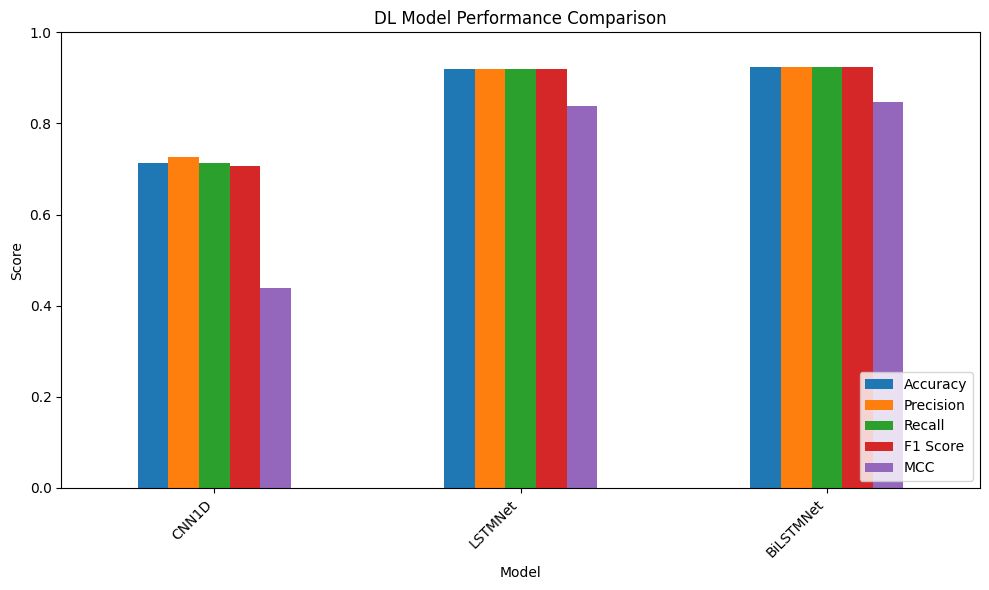

In [14]:
# ================================
# 1. Import Libraries
# ================================
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import gc
from tqdm import tqdm
import glob

# Set device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Primary processing device: {DEVICE}")

# ================================
# 2. Load & Merge Embeddings
# ================================
# ================================
# Load & Merge Embeddings (manual list)
# ================================
# Word embeddings (2 files)
word_files = [
    "/kaggle/input/word2vec/word2vec_url_embeddings.parquet",
    "/kaggle/input/fasttext/fasttext_url_embeddings.parquet"
]
df_word_list = [pd.read_parquet(f) for f in word_files]
df_word = pd.concat(df_word_list, axis=1)
df_word = df_word.loc[:, ~df_word.columns.duplicated()]  # remove duplicate columns if any

# Transformer embeddings (3 files)
trans_files = [
    "/kaggle/input/bertem/bert_url_embeddings.parquet",
    "/kaggle/input/roberta/roberta_url_embeddings.parquet",
    "/kaggle/input/minibert/minilm_url_embeddings.parquet"
]
df_trans_list = [pd.read_parquet(f) for f in trans_files]
df_trans = pd.concat(df_trans_list, axis=1)
df_trans = df_trans.loc[:, ~df_trans.columns.duplicated()]  # remove duplicate columns if any


# Original dataset for labels
df_orig = pd.read_csv("/kaggle/input/data-phishing/dataset_phishing.csv")  # must contain "status" column
le = LabelEncoder()
y = le.fit_transform(df_orig["status"].values)  # 0=legitimate, 1=phishing

# ================================
# 3. Prepare Input Features
# ================================
# Choose embedding type:
# X = df_word.drop(columns=["url"]).values
X = df_trans.drop(columns=["url"]).values

X = X.astype(np.float32)
y = y.astype(np.int64)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Convert to tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_test_t  = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=64, shuffle=False)

input_dim = X_train.shape[1]  # embedding dimension

# ================================
# 4. Define DL Models
# ================================
class CNN1D(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 64, 3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.fc = nn.Linear(64, 2)
    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.relu(self.conv1(x))
        x = self.pool(x).squeeze(-1)
        return self.fc(x)

class LSTMNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, 64, batch_first=True)
        self.fc = nn.Linear(64, 2)
    def forward(self, x):
        x = x.unsqueeze(1)
        _, (h_n, _) = self.lstm(x)
        return self.fc(h_n[-1])

class BiLSTMNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, 64, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(128, 2)
    def forward(self, x):
        x = x.unsqueeze(1)
        _, (h_n, _) = self.lstm(x)
        h_cat = torch.cat([h_n[-2], h_n[-1]], dim=-1)
        return self.fc(h_cat)

# ================================
# 5. Training & Evaluation Function
# ================================
def train_and_evaluate(model, train_loader, test_loader, epochs=50, lr=1e-3, patience=5):
    """
    Train model with early stopping.
    
    Args:
        model: PyTorch model
        train_loader: DataLoader for training data
        test_loader: DataLoader for validation/testing data
        epochs: max epochs
        lr: learning rate
        patience: how many epochs to wait for improvement before stopping
    """
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_loss = np.inf
    best_model_state = None
    counter = 0  # epochs without improvement

    for epoch in range(epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()

        # Validation loss
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                out = model(xb)
                val_loss += criterion(out, yb).item()
        val_loss /= len(test_loader)

        print(f"Epoch {epoch+1}/{epochs}, Val Loss: {val_loss:.4f}")

        # Early Stopping check
        if val_loss < best_loss:
            best_loss = val_loss
            best_model_state = model.state_dict()
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print(f"Early stopping triggered after {epoch+1} epochs.")
                break

    # Load best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    # Evaluation
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            out = model(xb)
            preds = out.argmax(dim=1).cpu().numpy()
            y_pred.extend(preds)
            y_true.extend(yb.cpu().numpy())

    # Metrics
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec  = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1   = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    mcc  = matthews_corrcoef(y_true, y_pred)

    print(f"Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}, MCC: {mcc:.4f}")

    return [model.__class__.__name__, acc, prec, rec, f1, mcc]

# ================================
# 6. Train & Evaluate All Models
# ================================
metrics_results = []
for ModelCls in [CNN1D, LSTMNet, BiLSTMNet]:
    print(f"\n=== {ModelCls.__name__} ===")
    metrics_results.append(train_and_evaluate(ModelCls(input_dim), train_loader, test_loader, epochs=5))
    gc.collect()

# ================================
# 7. Compare Models
# ================================
results_df = pd.DataFrame(metrics_results, columns=["Model", "Accuracy","Precision","Recall","F1 Score","MCC"])
print("\n=== DL Model Performance Comparison ===")
print(results_df)

# Bar plot
results_df.set_index("Model")[["Accuracy","Precision","Recall","F1 Score","MCC"]].plot(
    kind="bar", figsize=(10,6)
)
plt.title("DL Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0,1)
plt.legend(loc="lower right")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [ ]:
# word + LLM Embeddings

Primary processing device: cuda

=== CNN1D ===
Epoch 1/5, Val Loss: 0.7018
Epoch 2/5, Val Loss: 0.6991
Epoch 3/5, Val Loss: 0.7051
Epoch 4/5, Val Loss: 0.7748
Epoch 5/5, Val Loss: 0.6793
Accuracy: 0.5586, Precision: 0.5966, Recall: 0.5586, F1: 0.5105, MCC: 0.1505

=== LSTMNet ===
Epoch 1/5, Val Loss: 0.1694
Epoch 2/5, Val Loss: 0.1401
Epoch 3/5, Val Loss: 0.1460
Epoch 4/5, Val Loss: 0.1335
Epoch 5/5, Val Loss: 0.1273
Accuracy: 0.9541, Precision: 0.9546, Recall: 0.9541, F1: 0.9541, MCC: 0.9087

=== BiLSTMNet ===
Epoch 1/5, Val Loss: 0.1663
Epoch 2/5, Val Loss: 0.1597
Epoch 3/5, Val Loss: 0.1382
Epoch 4/5, Val Loss: 0.1217
Epoch 5/5, Val Loss: 0.1243
Accuracy: 0.9532, Precision: 0.9538, Recall: 0.9532, F1: 0.9532, MCC: 0.9070

=== DL Model Performance Comparison ===
       Model  Accuracy  Precision    Recall  F1 Score       MCC
0      CNN1D  0.558618   0.596649  0.558618  0.510459  0.150537
1    LSTMNet  0.954068   0.954597  0.954068  0.954055  0.908666
2  BiLSTMNet  0.953193   0.953836

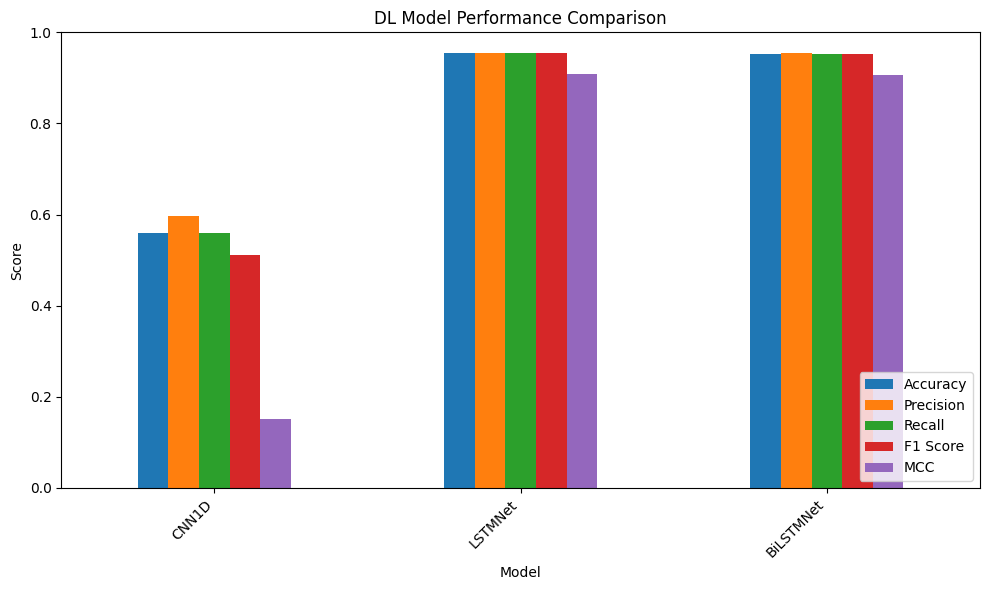

In [15]:
# ================================
# 1. Import Libraries
# ================================
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import gc
from tqdm import tqdm
import glob

# Set device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Primary processing device: {DEVICE}")

# ================================
# 2. Load & Merge Embeddings
# ================================
# ================================
# Load & Merge Embeddings (manual list)
# ================================
# Word embeddings (2 files)
word_files = [
    "/kaggle/input/word2vec/word2vec_url_embeddings.parquet",
    "/kaggle/input/fasttext/fasttext_url_embeddings.parquet"
]
df_word_list = [pd.read_parquet(f) for f in word_files]
df_word = pd.concat(df_word_list, axis=1)
df_word = df_word.loc[:, ~df_word.columns.duplicated()]  # remove duplicate columns if any

# Transformer embeddings (3 files)
llm_files = [
    "/kaggle/input/qwenem/qwen_url_embeddings.parquet",
    "/kaggle/input/falcon/falcon_url_embeddings.parquet"
]
df_trans_list = [pd.read_parquet(f) for f in llm_files]
df_trans = pd.concat(df_trans_list, axis=1)
df_trans = df_trans.loc[:, ~df_trans.columns.duplicated()]  # remove duplicate columns if any


# Original dataset for labels
df_orig = pd.read_csv("/kaggle/input/data-phishing/dataset_phishing.csv")  # must contain "status" column
le = LabelEncoder()
y = le.fit_transform(df_orig["status"].values)  # 0=legitimate, 1=phishing

# ================================
# 3. Prepare Input Features
# ================================
# Choose embedding type:
# X = df_word.drop(columns=["url"]).values
X = df_trans.drop(columns=["url"]).values

X = X.astype(np.float32)
y = y.astype(np.int64)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Convert to tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_test_t  = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=64, shuffle=False)

input_dim = X_train.shape[1]  # embedding dimension

# ================================
# 4. Define DL Models
# ================================
class CNN1D(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 64, 3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.fc = nn.Linear(64, 2)
    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.relu(self.conv1(x))
        x = self.pool(x).squeeze(-1)
        return self.fc(x)

class LSTMNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, 64, batch_first=True)
        self.fc = nn.Linear(64, 2)
    def forward(self, x):
        x = x.unsqueeze(1)
        _, (h_n, _) = self.lstm(x)
        return self.fc(h_n[-1])

class BiLSTMNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, 64, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(128, 2)
    def forward(self, x):
        x = x.unsqueeze(1)
        _, (h_n, _) = self.lstm(x)
        h_cat = torch.cat([h_n[-2], h_n[-1]], dim=-1)
        return self.fc(h_cat)

# ================================
# 5. Training & Evaluation Function
# ================================
def train_and_evaluate(model, train_loader, test_loader, epochs=50, lr=1e-3, patience=5):
    """
    Train model with early stopping.
    
    Args:
        model: PyTorch model
        train_loader: DataLoader for training data
        test_loader: DataLoader for validation/testing data
        epochs: max epochs
        lr: learning rate
        patience: how many epochs to wait for improvement before stopping
    """
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_loss = np.inf
    best_model_state = None
    counter = 0  # epochs without improvement

    for epoch in range(epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()

        # Validation loss
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                out = model(xb)
                val_loss += criterion(out, yb).item()
        val_loss /= len(test_loader)

        print(f"Epoch {epoch+1}/{epochs}, Val Loss: {val_loss:.4f}")

        # Early Stopping check
        if val_loss < best_loss:
            best_loss = val_loss
            best_model_state = model.state_dict()
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print(f"Early stopping triggered after {epoch+1} epochs.")
                break

    # Load best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    # Evaluation
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            out = model(xb)
            preds = out.argmax(dim=1).cpu().numpy()
            y_pred.extend(preds)
            y_true.extend(yb.cpu().numpy())

    # Metrics
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec  = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1   = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    mcc  = matthews_corrcoef(y_true, y_pred)

    print(f"Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}, MCC: {mcc:.4f}")

    return [model.__class__.__name__, acc, prec, rec, f1, mcc]

# ================================
# 6. Train & Evaluate All Models
# ================================
metrics_results = []
for ModelCls in [CNN1D, LSTMNet, BiLSTMNet]:
    print(f"\n=== {ModelCls.__name__} ===")
    metrics_results.append(train_and_evaluate(ModelCls(input_dim), train_loader, test_loader, epochs=5))
    gc.collect()

# ================================
# 7. Compare Models
# ================================
results_df = pd.DataFrame(metrics_results, columns=["Model", "Accuracy","Precision","Recall","F1 Score","MCC"])
print("\n=== DL Model Performance Comparison ===")
print(results_df)

# Bar plot
results_df.set_index("Model")[["Accuracy","Precision","Recall","F1 Score","MCC"]].plot(
    kind="bar", figsize=(10,6)
)
plt.title("DL Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0,1)
plt.legend(loc="lower right")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Transformers + LLM Embeddings

Primary processing device: cuda

=== CNN1D ===
Epoch 1/5, Val Loss: 0.7018
Epoch 2/5, Val Loss: 0.6887
Epoch 3/5, Val Loss: 0.8395
Epoch 4/5, Val Loss: 0.6815
Epoch 5/5, Val Loss: 0.7151
Accuracy: 0.5048, Precision: 0.6630, Recall: 0.5048, F1: 0.3462, MCC: 0.0560

=== LSTMNet ===
Epoch 1/5, Val Loss: 0.1824
Epoch 2/5, Val Loss: 0.1437
Epoch 3/5, Val Loss: 0.1324
Epoch 4/5, Val Loss: 0.1262
Epoch 5/5, Val Loss: 0.1323
Accuracy: 0.9532, Precision: 0.9549, Recall: 0.9532, F1: 0.9532, MCC: 0.9080

=== BiLSTMNet ===
Epoch 1/5, Val Loss: 0.1612
Epoch 2/5, Val Loss: 0.1370
Epoch 3/5, Val Loss: 0.1328
Epoch 4/5, Val Loss: 0.1240
Epoch 5/5, Val Loss: 0.1227
Accuracy: 0.9545, Precision: 0.9547, Recall: 0.9545, F1: 0.9545, MCC: 0.9092

=== DL Model Performance Comparison ===
       Model  Accuracy  Precision    Recall  F1 Score       MCC
0      CNN1D  0.504812   0.662977  0.504812  0.346184  0.056008
1    LSTMNet  0.953193   0.954851  0.953193  0.953151  0.908043
2  BiLSTMNet  0.954506   0.954674

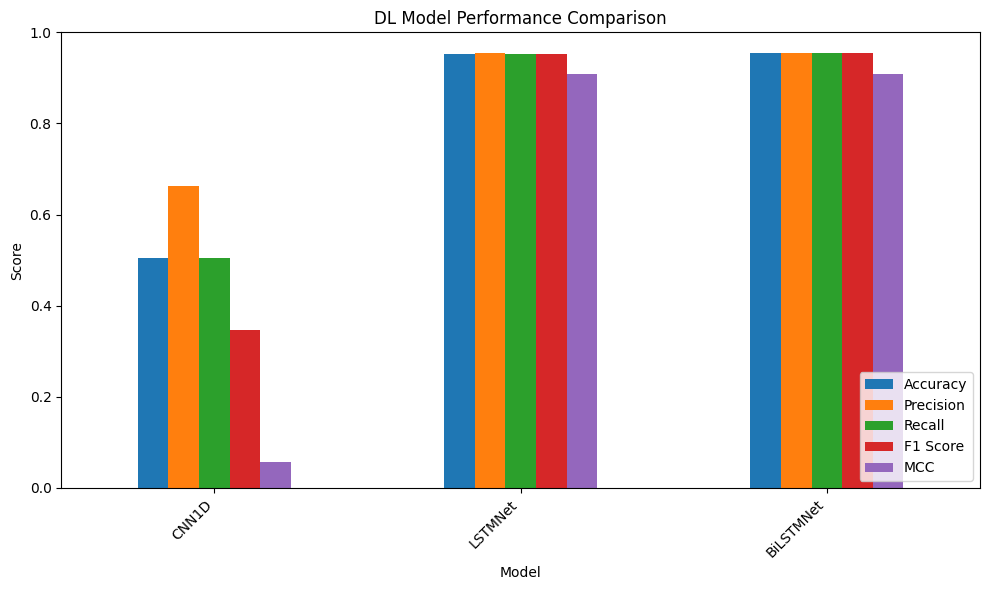

In [16]:
# ================================
# 1. Import Libraries
# ================================
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import gc
from tqdm import tqdm
import glob

# Set device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Primary processing device: {DEVICE}")

# ================================
# 2. Load & Merge Embeddings
# ================================
# ================================
# Load & Merge Embeddings (manual list)
# ================================
# Word embeddings (2 files)
transformer_files = [
    "/kaggle/input/bertem/bert_url_embeddings.parquet",
    "/kaggle/input/roberta/roberta_url_embeddings.parquet",
    "/kaggle/input/minibert/minilm_url_embeddings.parquet"
]
df_word_list = [pd.read_parquet(f) for f in transformer_files]
df_word = pd.concat(df_word_list, axis=1)
df_word = df_word.loc[:, ~df_word.columns.duplicated()]  # remove duplicate columns if any

# Transformer embeddings (3 files)
llm_files = [
    "/kaggle/input/qwenem/qwen_url_embeddings.parquet",
    "/kaggle/input/falcon/falcon_url_embeddings.parquet"
]
df_trans_list = [pd.read_parquet(f) for f in llm_files]
df_trans = pd.concat(df_trans_list, axis=1)
df_trans = df_trans.loc[:, ~df_trans.columns.duplicated()]  # remove duplicate columns if any


# Original dataset for labels
df_orig = pd.read_csv("/kaggle/input/data-phishing/dataset_phishing.csv")  # must contain "status" column
le = LabelEncoder()
y = le.fit_transform(df_orig["status"].values)  # 0=legitimate, 1=phishing

# ================================
# 3. Prepare Input Features
# ================================
# Choose embedding type:
# X = df_word.drop(columns=["url"]).values
X = df_trans.drop(columns=["url"]).values

X = X.astype(np.float32)
y = y.astype(np.int64)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Convert to tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_test_t  = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=64, shuffle=False)

input_dim = X_train.shape[1]  # embedding dimension

# ================================
# 4. Define DL Models
# ================================
class CNN1D(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 64, 3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.fc = nn.Linear(64, 2)
    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.relu(self.conv1(x))
        x = self.pool(x).squeeze(-1)
        return self.fc(x)

class LSTMNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, 64, batch_first=True)
        self.fc = nn.Linear(64, 2)
    def forward(self, x):
        x = x.unsqueeze(1)
        _, (h_n, _) = self.lstm(x)
        return self.fc(h_n[-1])

class BiLSTMNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, 64, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(128, 2)
    def forward(self, x):
        x = x.unsqueeze(1)
        _, (h_n, _) = self.lstm(x)
        h_cat = torch.cat([h_n[-2], h_n[-1]], dim=-1)
        return self.fc(h_cat)

# ================================
# 5. Training & Evaluation Function
# ================================
def train_and_evaluate(model, train_loader, test_loader, epochs=50, lr=1e-3, patience=5):
    """
    Train model with early stopping.
    
    Args:
        model: PyTorch model
        train_loader: DataLoader for training data
        test_loader: DataLoader for validation/testing data
        epochs: max epochs
        lr: learning rate
        patience: how many epochs to wait for improvement before stopping
    """
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_loss = np.inf
    best_model_state = None
    counter = 0  # epochs without improvement

    for epoch in range(epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()

        # Validation loss
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                out = model(xb)
                val_loss += criterion(out, yb).item()
        val_loss /= len(test_loader)

        print(f"Epoch {epoch+1}/{epochs}, Val Loss: {val_loss:.4f}")

        # Early Stopping check
        if val_loss < best_loss:
            best_loss = val_loss
            best_model_state = model.state_dict()
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print(f"Early stopping triggered after {epoch+1} epochs.")
                break

    # Load best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    # Evaluation
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            out = model(xb)
            preds = out.argmax(dim=1).cpu().numpy()
            y_pred.extend(preds)
            y_true.extend(yb.cpu().numpy())

    # Metrics
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec  = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1   = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    mcc  = matthews_corrcoef(y_true, y_pred)

    print(f"Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}, MCC: {mcc:.4f}")

    return [model.__class__.__name__, acc, prec, rec, f1, mcc]

# ================================
# 6. Train & Evaluate All Models
# ================================
metrics_results = []
for ModelCls in [CNN1D, LSTMNet, BiLSTMNet]:
    print(f"\n=== {ModelCls.__name__} ===")
    metrics_results.append(train_and_evaluate(ModelCls(input_dim), train_loader, test_loader, epochs=5))
    gc.collect()

# ================================
# 7. Compare Models
# ================================
results_df = pd.DataFrame(metrics_results, columns=["Model", "Accuracy","Precision","Recall","F1 Score","MCC"])
print("\n=== DL Model Performance Comparison ===")
print(results_df)

# Bar plot
results_df.set_index("Model")[["Accuracy","Precision","Recall","F1 Score","MCC"]].plot(
    kind="bar", figsize=(10,6)
)
plt.title("DL Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0,1)
plt.legend(loc="lower right")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Fusion with Attention

In [ ]:
# word + Transformers Embeddings

Device: cuda

=== CNN1D ===
Epoch 1/50, Train Loss: 0.2772, Val Loss: 0.2344
Epoch 2/50, Train Loss: 0.1716, Val Loss: 0.1621
Epoch 3/50, Train Loss: 0.1514, Val Loss: 0.1647
Epoch 4/50, Train Loss: 0.1253, Val Loss: 0.1758
Epoch 5/50, Train Loss: 0.1142, Val Loss: 0.1508
Epoch 6/50, Train Loss: 0.1071, Val Loss: 0.1523
Epoch 7/50, Train Loss: 0.0860, Val Loss: 0.1566
Epoch 8/50, Train Loss: 0.0861, Val Loss: 0.1799
Epoch 9/50, Train Loss: 0.0735, Val Loss: 0.1754
Epoch 10/50, Train Loss: 0.0541, Val Loss: 0.1606
Early stopping triggered at epoch 10

=== LSTMNet ===
Epoch 1/50, Train Loss: 0.1310, Val Loss: 0.1624
Epoch 2/50, Train Loss: 0.0813, Val Loss: 0.1457
Epoch 3/50, Train Loss: 0.0608, Val Loss: 0.2395
Epoch 4/50, Train Loss: 0.0513, Val Loss: 0.1810
Epoch 5/50, Train Loss: 0.0427, Val Loss: 0.2454
Epoch 6/50, Train Loss: 0.0402, Val Loss: 0.1996
Epoch 7/50, Train Loss: 0.0233, Val Loss: 0.2482
Early stopping triggered at epoch 7

=== BiLSTMNet ===
Epoch 1/50, Train Loss: 0.085

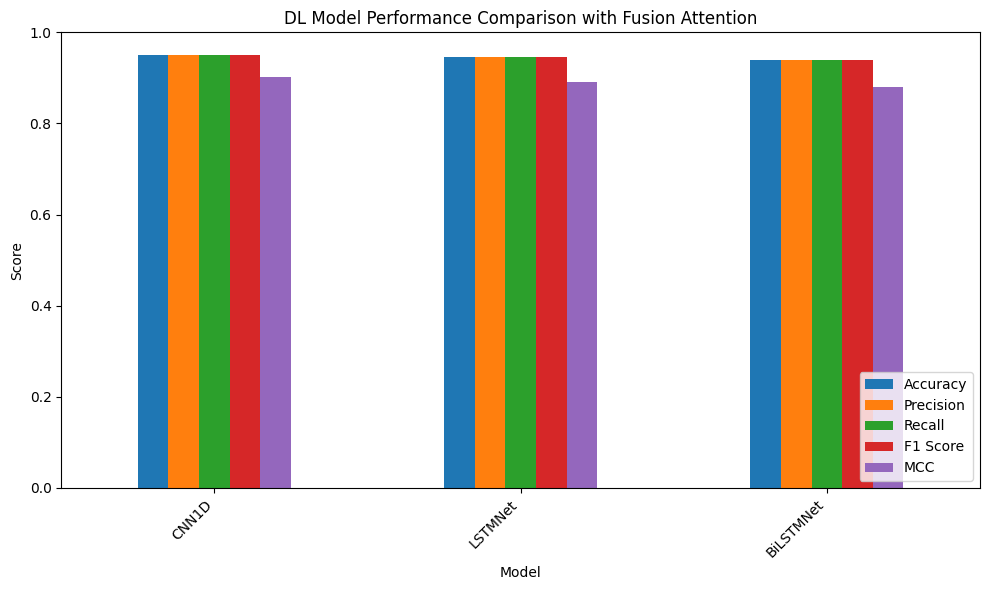

In [10]:
# ================================
# 1. Imports
# ================================
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef
import matplotlib.pyplot as plt
import seaborn as sns
import gc
from tqdm import tqdm

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# ================================
# 2. Load embeddings
# ================================
word_parquets = [
    "/kaggle/input/word2vec/word2vec_url_embeddings.parquet",
    "/kaggle/input/fasttext/fasttext_url_embeddings.parquet"
]
transformer_parquets = [
    "/kaggle/input/bertem/bert_url_embeddings.parquet",
    "/kaggle/input/roberta/roberta_url_embeddings.parquet",
    "/kaggle/input/minibert/minilm_url_embeddings.parquet"
]
original_dataset = "/kaggle/input/data-phishing/dataset_phishing.csv"  # must contain 'status'

# Load and concatenate embeddings
word_dfs = [pd.read_parquet(p) for p in word_parquets]
word_emb = pd.concat(word_dfs, axis=1)

trans_dfs = [pd.read_parquet(p) for p in transformer_parquets]
trans_emb = pd.concat(trans_dfs, axis=1)

# Ensure numeric
word_emb = word_emb.apply(pd.to_numeric, errors='coerce').fillna(0).values
trans_emb = trans_emb.apply(pd.to_numeric, errors='coerce').fillna(0).values

# Labels
df_orig = pd.read_csv(original_dataset)
le = LabelEncoder()
y = le.fit_transform(df_orig["status"].values)

# Train-Test split
X_word_train, X_word_test, X_trans_train, X_trans_test, y_train, y_test = train_test_split(
    word_emb, trans_emb, y, test_size=0.2, random_state=42, stratify=y
)

# Convert to torch tensors
X_word_train = torch.tensor(X_word_train, dtype=torch.float32).to(DEVICE)
X_word_test  = torch.tensor(X_word_test, dtype=torch.float32).to(DEVICE)
X_trans_train = torch.tensor(X_trans_train, dtype=torch.float32).to(DEVICE)
X_trans_test  = torch.tensor(X_trans_test, dtype=torch.float32).to(DEVICE)
y_train = torch.tensor(y_train, dtype=torch.long).to(DEVICE)
y_test  = torch.tensor(y_test, dtype=torch.long).to(DEVICE)

train_dataset = TensorDataset(X_word_train, X_trans_train, y_train)
test_dataset  = TensorDataset(X_word_test, X_trans_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64)

# ================================
# 3. Attention-based Fusion Module
# ================================
class FusionAttention(nn.Module):
    def __init__(self, word_dim, trans_dim, hidden_dim):
        super(FusionAttention, self).__init__()
        self.word_proj = nn.Linear(word_dim, hidden_dim)
        self.trans_proj = nn.Linear(trans_dim, hidden_dim)
        self.attn = nn.Linear(hidden_dim, 1)
        
    def forward(self, word_x, trans_x):
        word_h = torch.tanh(self.word_proj(word_x))
        trans_h = torch.tanh(self.trans_proj(trans_x))
        combined = torch.stack([word_h, trans_h], dim=1)  # (batch, 2, hidden_dim)
        attn_scores = F.softmax(self.attn(combined), dim=1)  # (batch, 2, 1)
        attn_applied = (combined * attn_scores).sum(dim=1)   # weighted sum
        return attn_applied

# ================================
# 4. DL Models with Fusion
# ================================
class CNN1D(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_classes=2):
        super(CNN1D, self).__init__()
        self.conv1 = nn.Conv1d(1, 32, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(32*input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, num_classes)
        
    def forward(self, x):
        x = x.unsqueeze(1)  # (batch, 1, features)
        x = F.relu(self.conv1(x))
        x = x.flatten(start_dim=1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

class LSTMNet(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_classes=2):
        super(LSTMNet, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_classes)
        
    def forward(self, x):
        x = x.unsqueeze(1)  # (batch, seq_len=1, features)
        _, (h_n, _) = self.lstm(x)
        out = self.fc(h_n[-1])
        return out

class BiLSTMNet(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_classes=2):
        super(BiLSTMNet, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim*2, num_classes)
        
    def forward(self, x):
        x = x.unsqueeze(1)
        _, (h_n, _) = self.lstm(x)
        h_n = torch.cat([h_n[-2], h_n[-1]], dim=1)
        out = self.fc(h_n)
        return out

# ================================
# 5. Training & Evaluation
# ================================
# ================================
# 5. Training & Evaluation with Early Stopping
# ================================
def train_and_evaluate(ModelCls, fusion, train_loader, test_loader, epochs=50, lr=1e-3, patience=5):
    """
    Train a model with FusionAttention and implement early stopping.
    
    Args:
        ModelCls: Class of the DL model (CNN1D, LSTMNet, BiLSTMNet)
        fusion: FusionAttention module
        train_loader: DataLoader for training
        test_loader: DataLoader for validation/testing
        epochs: maximum number of epochs
        lr: learning rate
        patience: early stopping patience
    Returns:
        List with model metrics [ModelName, Accuracy, Precision, Recall, F1, MCC]
    """
    model = ModelCls(input_dim=fusion_output_dim).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(list(fusion.parameters()) + list(model.parameters()), lr=lr)
    
    best_loss = float('inf')
    best_model_state = None
    patience_counter = 0
    
    for epoch in range(epochs):
        model.train()
        fusion.train()
        total_loss = 0
        
        for xb_word, xb_trans, yb in train_loader:
            optimizer.zero_grad()
            fused = fusion(xb_word, xb_trans)
            out = model(fused)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        
        avg_train_loss = total_loss / len(train_loader)
        
        # Validation loss
        model.eval()
        fusion.eval()
        val_loss = 0
        with torch.no_grad():
            for xb_word, xb_trans, yb in test_loader:
                fused = fusion(xb_word, xb_trans)
                out = model(fused)
                loss = criterion(out, yb)
                val_loss += loss.item()
        avg_val_loss = val_loss / len(test_loader)
        
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")
        
        # Early stopping
        if avg_val_loss < best_loss:
            best_loss = avg_val_loss
            best_model_state = {
                'model': model.state_dict(),
                'fusion': fusion.state_dict()
            }
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping triggered at epoch {epoch+1}")
                break
    
    # Load best model
    model.load_state_dict(best_model_state['model'])
    fusion.load_state_dict(best_model_state['fusion'])
    
    # Evaluation
    model.eval()
    fusion.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for xb_word, xb_trans, yb in test_loader:
            fused = fusion(xb_word, xb_trans)
            out = model(fused)
            preds = torch.argmax(out, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(yb.cpu().numpy())
    
    acc  = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average="weighted", zero_division=0)
    rec  = recall_score(all_labels, all_preds, average="weighted", zero_division=0)
    f1   = f1_score(all_labels, all_preds, average="weighted", zero_division=0)
    mcc  = matthews_corrcoef(all_labels, all_preds)
    
    return [ModelCls.__name__, acc, prec, rec, f1, mcc]
# ================================
# 6. Run Models
# ================================
fusion_hidden_dim = 256
fusion_output_dim = fusion_hidden_dim
fusion_module = FusionAttention(word_dim=X_word_train.shape[1], trans_dim=X_trans_train.shape[1],
                               hidden_dim=fusion_hidden_dim).to(DEVICE)

metrics_results = []

for ModelCls in [CNN1D, LSTMNet, BiLSTMNet]:
    print(f"\n=== {ModelCls.__name__} ===")
    metrics_results.append(train_and_evaluate(ModelCls, fusion_module, train_loader, test_loader, epochs=50))
    gc.collect()

# ================================
# 7. Compare Models
# ================================
results_df = pd.DataFrame(metrics_results, columns=["Model", "Accuracy","Precision","Recall","F1 Score","MCC"])
print("\n=== Model Performance Comparison ===")
print(results_df)

results_df.set_index("Model")[["Accuracy","Precision","Recall","F1 Score","MCC"]].plot(
    kind="bar", figsize=(10,6)
)
plt.title("DL Model Performance Comparison with Fusion Attention")
plt.ylabel("Score")
plt.ylim(0,1)
plt.legend(loc="lower right")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# word + LLM Embeddings

Device: cuda

=== CNN1D ===
Epoch 1/50, Train Loss: 0.5647, Val Loss: 0.4108
Epoch 2/50, Train Loss: 0.3624, Val Loss: 0.3884
Epoch 3/50, Train Loss: 0.2437, Val Loss: 0.1966
Epoch 4/50, Train Loss: 0.1926, Val Loss: 0.1537
Epoch 5/50, Train Loss: 0.1793, Val Loss: 0.1755
Epoch 6/50, Train Loss: 0.1661, Val Loss: 0.1558
Epoch 7/50, Train Loss: 0.1678, Val Loss: 0.1563
Epoch 8/50, Train Loss: 0.1491, Val Loss: 0.1468
Epoch 9/50, Train Loss: 0.1483, Val Loss: 0.1550
Epoch 10/50, Train Loss: 0.1408, Val Loss: 0.1438
Epoch 11/50, Train Loss: 0.1422, Val Loss: 0.1645
Epoch 12/50, Train Loss: 0.1260, Val Loss: 0.1381
Epoch 13/50, Train Loss: 0.1169, Val Loss: 0.1573
Epoch 14/50, Train Loss: 0.1216, Val Loss: 0.1368
Epoch 15/50, Train Loss: 0.1147, Val Loss: 0.1466
Epoch 16/50, Train Loss: 0.1042, Val Loss: 0.1335
Epoch 17/50, Train Loss: 0.1141, Val Loss: 0.1608
Epoch 18/50, Train Loss: 0.1010, Val Loss: 0.1217
Epoch 19/50, Train Loss: 0.0898, Val Loss: 0.1356
Epoch 20/50, Train Loss: 0.1005

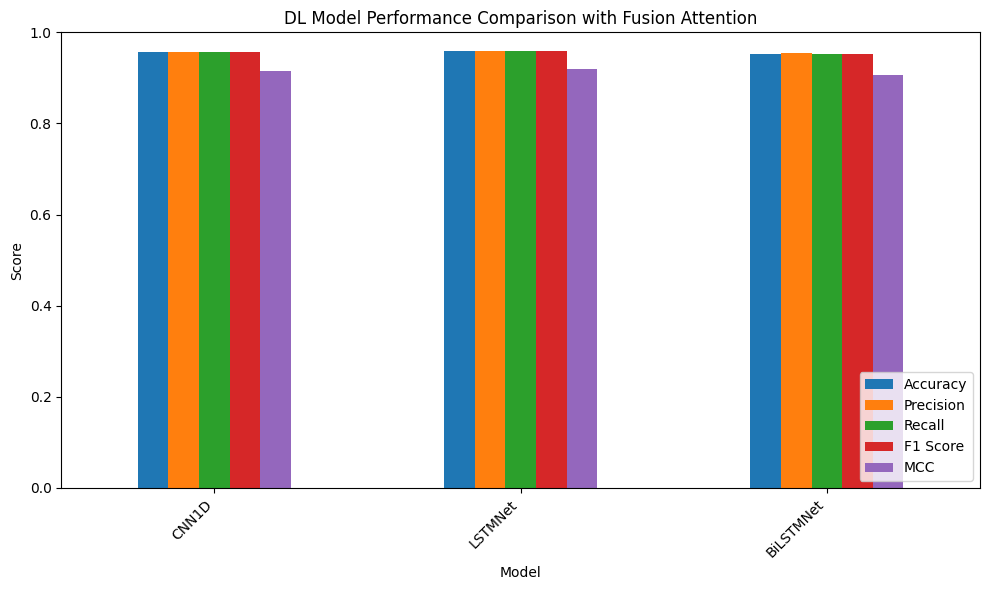

In [11]:
# ================================
# 1. Imports
# ================================
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef
import matplotlib.pyplot as plt
import seaborn as sns
import gc
from tqdm import tqdm

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# ================================
# 2. Load embeddings
# ================================
word_parquets = [
    "/kaggle/input/word2vec/word2vec_url_embeddings.parquet",
    "/kaggle/input/fasttext/fasttext_url_embeddings.parquet"
]
llm_files = [
    "/kaggle/input/qwenem/qwen_url_embeddings.parquet",
    "/kaggle/input/falcon/falcon_url_embeddings.parquet"
]
original_dataset = "/kaggle/input/data-phishing/dataset_phishing.csv"  # must contain 'status'

# Load and concatenate embeddings
word_dfs = [pd.read_parquet(p) for p in word_parquets]
word_emb = pd.concat(word_dfs, axis=1)

trans_dfs = [pd.read_parquet(p) for p in llm_parquets]
trans_emb = pd.concat(trans_dfs, axis=1)

# Ensure numeric
word_emb = word_emb.apply(pd.to_numeric, errors='coerce').fillna(0).values
trans_emb = trans_emb.apply(pd.to_numeric, errors='coerce').fillna(0).values

# Labels
df_orig = pd.read_csv(original_dataset)
le = LabelEncoder()
y = le.fit_transform(df_orig["status"].values)

# Train-Test split
X_word_train, X_word_test, X_trans_train, X_trans_test, y_train, y_test = train_test_split(
    word_emb, trans_emb, y, test_size=0.2, random_state=42, stratify=y
)

# Convert to torch tensors
X_word_train = torch.tensor(X_word_train, dtype=torch.float32).to(DEVICE)
X_word_test  = torch.tensor(X_word_test, dtype=torch.float32).to(DEVICE)
X_trans_train = torch.tensor(X_trans_train, dtype=torch.float32).to(DEVICE)
X_trans_test  = torch.tensor(X_trans_test, dtype=torch.float32).to(DEVICE)
y_train = torch.tensor(y_train, dtype=torch.long).to(DEVICE)
y_test  = torch.tensor(y_test, dtype=torch.long).to(DEVICE)

train_dataset = TensorDataset(X_word_train, X_trans_train, y_train)
test_dataset  = TensorDataset(X_word_test, X_trans_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64)

# ================================
# 3. Attention-based Fusion Module
# ================================
class FusionAttention(nn.Module):
    def __init__(self, word_dim, trans_dim, hidden_dim):
        super(FusionAttention, self).__init__()
        self.word_proj = nn.Linear(word_dim, hidden_dim)
        self.trans_proj = nn.Linear(trans_dim, hidden_dim)
        self.attn = nn.Linear(hidden_dim, 1)
        
    def forward(self, word_x, trans_x):
        word_h = torch.tanh(self.word_proj(word_x))
        trans_h = torch.tanh(self.trans_proj(trans_x))
        combined = torch.stack([word_h, trans_h], dim=1)  # (batch, 2, hidden_dim)
        attn_scores = F.softmax(self.attn(combined), dim=1)  # (batch, 2, 1)
        attn_applied = (combined * attn_scores).sum(dim=1)   # weighted sum
        return attn_applied

# ================================
# 4. DL Models with Fusion
# ================================
class CNN1D(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_classes=2):
        super(CNN1D, self).__init__()
        self.conv1 = nn.Conv1d(1, 32, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(32*input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, num_classes)
        
    def forward(self, x):
        x = x.unsqueeze(1)  # (batch, 1, features)
        x = F.relu(self.conv1(x))
        x = x.flatten(start_dim=1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

class LSTMNet(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_classes=2):
        super(LSTMNet, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_classes)
        
    def forward(self, x):
        x = x.unsqueeze(1)  # (batch, seq_len=1, features)
        _, (h_n, _) = self.lstm(x)
        out = self.fc(h_n[-1])
        return out

class BiLSTMNet(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_classes=2):
        super(BiLSTMNet, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim*2, num_classes)
        
    def forward(self, x):
        x = x.unsqueeze(1)
        _, (h_n, _) = self.lstm(x)
        h_n = torch.cat([h_n[-2], h_n[-1]], dim=1)
        out = self.fc(h_n)
        return out

# ================================
# 5. Training & Evaluation
# ================================
# ================================
# 5. Training & Evaluation with Early Stopping
# ================================
def train_and_evaluate(ModelCls, fusion, train_loader, test_loader, epochs=50, lr=1e-3, patience=5):
    """
    Train a model with FusionAttention and implement early stopping.
    
    Args:
        ModelCls: Class of the DL model (CNN1D, LSTMNet, BiLSTMNet)
        fusion: FusionAttention module
        train_loader: DataLoader for training
        test_loader: DataLoader for validation/testing
        epochs: maximum number of epochs
        lr: learning rate
        patience: early stopping patience
    Returns:
        List with model metrics [ModelName, Accuracy, Precision, Recall, F1, MCC]
    """
    model = ModelCls(input_dim=fusion_output_dim).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(list(fusion.parameters()) + list(model.parameters()), lr=lr)
    
    best_loss = float('inf')
    best_model_state = None
    patience_counter = 0
    
    for epoch in range(epochs):
        model.train()
        fusion.train()
        total_loss = 0
        
        for xb_word, xb_trans, yb in train_loader:
            optimizer.zero_grad()
            fused = fusion(xb_word, xb_trans)
            out = model(fused)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        
        avg_train_loss = total_loss / len(train_loader)
        
        # Validation loss
        model.eval()
        fusion.eval()
        val_loss = 0
        with torch.no_grad():
            for xb_word, xb_trans, yb in test_loader:
                fused = fusion(xb_word, xb_trans)
                out = model(fused)
                loss = criterion(out, yb)
                val_loss += loss.item()
        avg_val_loss = val_loss / len(test_loader)
        
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")
        
        # Early stopping
        if avg_val_loss < best_loss:
            best_loss = avg_val_loss
            best_model_state = {
                'model': model.state_dict(),
                'fusion': fusion.state_dict()
            }
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping triggered at epoch {epoch+1}")
                break
    
    # Load best model
    model.load_state_dict(best_model_state['model'])
    fusion.load_state_dict(best_model_state['fusion'])
    
    # Evaluation
    model.eval()
    fusion.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for xb_word, xb_trans, yb in test_loader:
            fused = fusion(xb_word, xb_trans)
            out = model(fused)
            preds = torch.argmax(out, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(yb.cpu().numpy())
    
    acc  = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average="weighted", zero_division=0)
    rec  = recall_score(all_labels, all_preds, average="weighted", zero_division=0)
    f1   = f1_score(all_labels, all_preds, average="weighted", zero_division=0)
    mcc  = matthews_corrcoef(all_labels, all_preds)
    
    return [ModelCls.__name__, acc, prec, rec, f1, mcc]
# ================================
# 6. Run Models
# ================================
fusion_hidden_dim = 256
fusion_output_dim = fusion_hidden_dim
fusion_module = FusionAttention(word_dim=X_word_train.shape[1], trans_dim=X_trans_train.shape[1],
                               hidden_dim=fusion_hidden_dim).to(DEVICE)

metrics_results = []

for ModelCls in [CNN1D, LSTMNet, BiLSTMNet]:
    print(f"\n=== {ModelCls.__name__} ===")
    metrics_results.append(train_and_evaluate(ModelCls, fusion_module, train_loader, test_loader, epochs=50))
    gc.collect()

# ================================
# 7. Compare Models
# ================================
results_df = pd.DataFrame(metrics_results, columns=["Model", "Accuracy","Precision","Recall","F1 Score","MCC"])
print("\n=== Model Performance Comparison ===")
print(results_df)

results_df.set_index("Model")[["Accuracy","Precision","Recall","F1 Score","MCC"]].plot(
    kind="bar", figsize=(10,6)
)
plt.title("DL Model Performance Comparison with Fusion Attention")
plt.ylabel("Score")
plt.ylim(0,1)
plt.legend(loc="lower right")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Transformers + LLM Embeddings

Device: cuda

=== CNN1D ===
Epoch 1/50, Train Loss: 0.2562, Val Loss: 0.2354
Epoch 2/50, Train Loss: 0.1636, Val Loss: 0.1491
Epoch 3/50, Train Loss: 0.1312, Val Loss: 0.1376
Epoch 4/50, Train Loss: 0.1337, Val Loss: 0.1324
Epoch 5/50, Train Loss: 0.1124, Val Loss: 0.1689
Epoch 6/50, Train Loss: 0.0977, Val Loss: 0.1571
Epoch 7/50, Train Loss: 0.0968, Val Loss: 0.1901
Epoch 8/50, Train Loss: 0.0997, Val Loss: 0.1302
Epoch 9/50, Train Loss: 0.0769, Val Loss: 0.1909
Epoch 10/50, Train Loss: 0.0792, Val Loss: 0.1811
Epoch 11/50, Train Loss: 0.0546, Val Loss: 0.1628
Epoch 12/50, Train Loss: 0.0677, Val Loss: 0.2101
Epoch 13/50, Train Loss: 0.0430, Val Loss: 0.1729
Early stopping triggered at epoch 13

=== LSTMNet ===
Epoch 1/50, Train Loss: 0.1069, Val Loss: 0.1577
Epoch 2/50, Train Loss: 0.0695, Val Loss: 0.1532
Epoch 3/50, Train Loss: 0.0361, Val Loss: 0.1831
Epoch 4/50, Train Loss: 0.0594, Val Loss: 0.1507
Epoch 5/50, Train Loss: 0.0380, Val Loss: 0.1871
Epoch 6/50, Train Loss: 0.0225, 

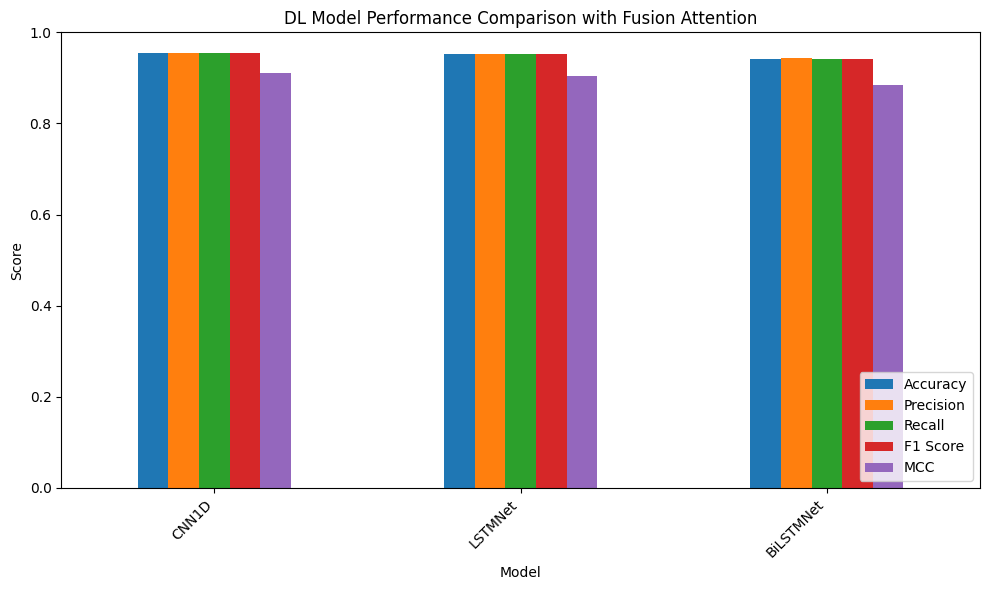

In [12]:
# ================================
# 1. Imports
# ================================
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef
import matplotlib.pyplot as plt
import seaborn as sns
import gc
from tqdm import tqdm

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# ================================
# 2. Load embeddings
# ================================
transformer_parquets = [
    "/kaggle/input/bertem/bert_url_embeddings.parquet",
    "/kaggle/input/roberta/roberta_url_embeddings.parquet",
    "/kaggle/input/minibert/minilm_url_embeddings.parquet"
]
llm_files = [
    "/kaggle/input/qwenem/qwen_url_embeddings.parquet",
    "/kaggle/input/falcon/falcon_url_embeddings.parquet"
]
original_dataset = "/kaggle/input/data-phishing/dataset_phishing.csv"  # must contain 'status'

# Load and concatenate embeddings
word_dfs = [pd.read_parquet(p) for p in transformer_parquets]
word_emb = pd.concat(word_dfs, axis=1)

trans_dfs = [pd.read_parquet(p) for p in llm_parquets]
trans_emb = pd.concat(trans_dfs, axis=1)

# Ensure numeric
word_emb = word_emb.apply(pd.to_numeric, errors='coerce').fillna(0).values
trans_emb = trans_emb.apply(pd.to_numeric, errors='coerce').fillna(0).values

# Labels
df_orig = pd.read_csv(original_dataset)
le = LabelEncoder()
y = le.fit_transform(df_orig["status"].values)

# Train-Test split
X_word_train, X_word_test, X_trans_train, X_trans_test, y_train, y_test = train_test_split(
    word_emb, trans_emb, y, test_size=0.2, random_state=42, stratify=y
)

# Convert to torch tensors
X_word_train = torch.tensor(X_word_train, dtype=torch.float32).to(DEVICE)
X_word_test  = torch.tensor(X_word_test, dtype=torch.float32).to(DEVICE)
X_trans_train = torch.tensor(X_trans_train, dtype=torch.float32).to(DEVICE)
X_trans_test  = torch.tensor(X_trans_test, dtype=torch.float32).to(DEVICE)
y_train = torch.tensor(y_train, dtype=torch.long).to(DEVICE)
y_test  = torch.tensor(y_test, dtype=torch.long).to(DEVICE)

train_dataset = TensorDataset(X_word_train, X_trans_train, y_train)
test_dataset  = TensorDataset(X_word_test, X_trans_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64)

# ================================
# 3. Attention-based Fusion Module
# ================================
class FusionAttention(nn.Module):
    def __init__(self, word_dim, trans_dim, hidden_dim):
        super(FusionAttention, self).__init__()
        self.word_proj = nn.Linear(word_dim, hidden_dim)
        self.trans_proj = nn.Linear(trans_dim, hidden_dim)
        self.attn = nn.Linear(hidden_dim, 1)
        
    def forward(self, word_x, trans_x):
        word_h = torch.tanh(self.word_proj(word_x))
        trans_h = torch.tanh(self.trans_proj(trans_x))
        combined = torch.stack([word_h, trans_h], dim=1)  # (batch, 2, hidden_dim)
        attn_scores = F.softmax(self.attn(combined), dim=1)  # (batch, 2, 1)
        attn_applied = (combined * attn_scores).sum(dim=1)   # weighted sum
        return attn_applied

# ================================
# 4. DL Models with Fusion
# ================================
class CNN1D(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_classes=2):
        super(CNN1D, self).__init__()
        self.conv1 = nn.Conv1d(1, 32, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(32*input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, num_classes)
        
    def forward(self, x):
        x = x.unsqueeze(1)  # (batch, 1, features)
        x = F.relu(self.conv1(x))
        x = x.flatten(start_dim=1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

class LSTMNet(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_classes=2):
        super(LSTMNet, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_classes)
        
    def forward(self, x):
        x = x.unsqueeze(1)  # (batch, seq_len=1, features)
        _, (h_n, _) = self.lstm(x)
        out = self.fc(h_n[-1])
        return out

class BiLSTMNet(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_classes=2):
        super(BiLSTMNet, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim*2, num_classes)
        
    def forward(self, x):
        x = x.unsqueeze(1)
        _, (h_n, _) = self.lstm(x)
        h_n = torch.cat([h_n[-2], h_n[-1]], dim=1)
        out = self.fc(h_n)
        return out

# ================================
# 5. Training & Evaluation
# ================================
# ================================
# 5. Training & Evaluation with Early Stopping
# ================================
def train_and_evaluate(ModelCls, fusion, train_loader, test_loader, epochs=50, lr=1e-3, patience=5):
    """
    Train a model with FusionAttention and implement early stopping.
    
    Args:
        ModelCls: Class of the DL model (CNN1D, LSTMNet, BiLSTMNet)
        fusion: FusionAttention module
        train_loader: DataLoader for training
        test_loader: DataLoader for validation/testing
        epochs: maximum number of epochs
        lr: learning rate
        patience: early stopping patience
    Returns:
        List with model metrics [ModelName, Accuracy, Precision, Recall, F1, MCC]
    """
    model = ModelCls(input_dim=fusion_output_dim).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(list(fusion.parameters()) + list(model.parameters()), lr=lr)
    
    best_loss = float('inf')
    best_model_state = None
    patience_counter = 0
    
    for epoch in range(epochs):
        model.train()
        fusion.train()
        total_loss = 0
        
        for xb_word, xb_trans, yb in train_loader:
            optimizer.zero_grad()
            fused = fusion(xb_word, xb_trans)
            out = model(fused)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        
        avg_train_loss = total_loss / len(train_loader)
        
        # Validation loss
        model.eval()
        fusion.eval()
        val_loss = 0
        with torch.no_grad():
            for xb_word, xb_trans, yb in test_loader:
                fused = fusion(xb_word, xb_trans)
                out = model(fused)
                loss = criterion(out, yb)
                val_loss += loss.item()
        avg_val_loss = val_loss / len(test_loader)
        
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")
        
        # Early stopping
        if avg_val_loss < best_loss:
            best_loss = avg_val_loss
            best_model_state = {
                'model': model.state_dict(),
                'fusion': fusion.state_dict()
            }
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping triggered at epoch {epoch+1}")
                break
    
    # Load best model
    model.load_state_dict(best_model_state['model'])
    fusion.load_state_dict(best_model_state['fusion'])
    
    # Evaluation
    model.eval()
    fusion.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for xb_word, xb_trans, yb in test_loader:
            fused = fusion(xb_word, xb_trans)
            out = model(fused)
            preds = torch.argmax(out, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(yb.cpu().numpy())
    
    acc  = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average="weighted", zero_division=0)
    rec  = recall_score(all_labels, all_preds, average="weighted", zero_division=0)
    f1   = f1_score(all_labels, all_preds, average="weighted", zero_division=0)
    mcc  = matthews_corrcoef(all_labels, all_preds)
    
    return [ModelCls.__name__, acc, prec, rec, f1, mcc]
# ================================
# 6. Run Models
# ================================
fusion_hidden_dim = 256
fusion_output_dim = fusion_hidden_dim
fusion_module = FusionAttention(word_dim=X_word_train.shape[1], trans_dim=X_trans_train.shape[1],
                               hidden_dim=fusion_hidden_dim).to(DEVICE)

metrics_results = []

for ModelCls in [CNN1D, LSTMNet, BiLSTMNet]:
    print(f"\n=== {ModelCls.__name__} ===")
    metrics_results.append(train_and_evaluate(ModelCls, fusion_module, train_loader, test_loader, epochs=50))
    gc.collect()

# ================================
# 7. Compare Models
# ================================
results_df = pd.DataFrame(metrics_results, columns=["Model", "Accuracy","Precision","Recall","F1 Score","MCC"])
print("\n=== Model Performance Comparison ===")
print(results_df)

results_df.set_index("Model")[["Accuracy","Precision","Recall","F1 Score","MCC"]].plot(
    kind="bar", figsize=(10,6)
)
plt.title("DL Model Performance Comparison with Fusion Attention")
plt.ylabel("Score")
plt.ylim(0,1)
plt.legend(loc="lower right")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()